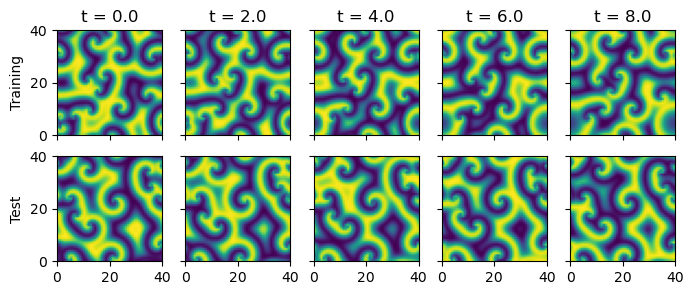

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import torch
torch.set_grad_enabled(False)
torch.set_default_dtype(torch.double)

 #plt.rcParams.update({
 #    "text.usetex": True,
 #    "font.family": "serif",
 #    "font.size": 11
 #})

L = 40
dt = 0.2

C = torch.load(f"spiralwaves_train.pt", weights_only=True)
C_test = torch.load(f"spiralwaves_test.pt", weights_only=True)

def plot_trajectory(C, ax):
    n_plots = len(ax)
    for i in range(n_plots): 
        ax[i].imshow(C[int(len(C)*i/n_plots)], extent=[0,L,0,L])
        ax[i].set_aspect('equal')
        ax[i].set_xlim(0, L)
        ax[i].set_ylim(0, L)

n_plots, n_steps = 5, 50
fig, ax = plt.subplots(2, n_plots, figsize=(n_plots*1.6, 3), sharey=True, sharex=True)
plot_trajectory(C[:n_steps,0], ax[0])
plot_trajectory(C_test[:n_steps,0], ax[1])
for i in range(n_plots): ax[0,i].set_title(f"t = {i/n_plots*dt*n_steps:.1f}")
ax[0,0].set_ylabel("Training")
ax[1,0].set_ylabel("Test")
plt.show()

In [23]:
import warnings; warnings.filterwarnings("ignore")
import tqdm
# import conjugate_gradients as cg

class Observer(torch.nn.Module):

    def __init__(self, n_obs=10):
        super().__init__()
        self.n_obs = n_obs
        self.conv = torch.nn.Conv2d(2, n_obs, 1, padding="same", padding_mode="circular")
        self.nl = torch.nn.Softplus()

    def forward(self, x):
        x = self.conv(x)
        x = self.nl(x)
        return x
    
class Reconstructor(torch.nn.Module):

    def __init__(self, obsC, C):
        super().__init__()
        self.n_obs = torch.tensor(obsC.shape[1])
        self.conv = torch.nn.Conv2d(self.n_obs, 2, 1, padding="same", padding_mode="circular")
        self.train(obsC, C)

    def train(self, obsC, C):
        torch.set_grad_enabled(True)
        opt = torch.optim.Adam(self.parameters(), lr=1e-1)
        for _ in ( pbar := tqdm.tqdm(range(100))):
            opt.zero_grad()
            loss = (self(obsC) - C).pow(2).mean()
            loss.backward()
            opt.step()
            pbar.set_description(f"loss: {loss.item():.3e}")
        torch.set_grad_enabled(False)

    def forward(self, x):
        x = self.conv(x)
        return x

obs = Observer(n_obs=30)
rec = Reconstructor(obs(C), C)

loss: 1.809e-03: 100%|██████████| 100/100 [00:03<00:00, 30.67it/s]


In [24]:
import itertools 
    
class ConvEDMD_FFT(torch.nn.Module):
    def __init__(self, n_obs, X, Y, dt):
        super().__init__()
        self.G = (X.shape[-2], X.shape[-1])
        self.n_obs = n_obs
        self.A_hat = torch.zeros( n_obs, n_obs, *self.G, dtype=torch.complex128)
        self.train(X, Y)
        self.dt = dt

    def train(self, X, Y):
        X_hat = torch.fft.fft2(X)
        Y_hat = torch.fft.fft2(Y)
        for rho_g1, rho_g2 in itertools.product(*(range(i) for i in self.G)):
            X_ = X_hat[...,rho_g1,rho_g2]
            Y_ = Y_hat[...,rho_g1,rho_g2]
            self.A_hat[...,rho_g1,rho_g2] = torch.linalg.lstsq(X_, Y_, driver="gelsd").solution.T
        self.A = torch.fft.ifft2(self.A_hat)

    def forward(self, x):
        squeezed = len(x.shape) == 3
        if squeezed: x = x.unsqueeze(0)

        x_hat = torch.fft.fft2(x)
        y_hat = torch.einsum("ijkl,bjkl -> bikl", self.A_hat, x_hat)
        y = torch.fft.ifft2(y_hat)

        if squeezed: y = y.squeeze(0)
        return y

    def A_transposed(self):
        # exchange s and s'
        AT = self.A.transpose(0,1)
        # inverts g
        AT = AT.flip(dims=[2,3])
        AT = AT.roll([1,1], dims=[2,3]) 
        return AT
    
    def eigvals_right(self):
        eigvals_A, _ = torch.linalg.eig( self.A_hat.permute(2,3,0,1) )
        eigvals_A = eigvals_A.flatten()
        return eigvals_A
    
    def eigenpairs_left(self, n_group_samples):
        AT = self.A_transposed()
        AT_hat = torch.fft.fft2(AT)

        # eigenvals_A: (*G, n_obs)
        # eigenvecs_A_hat: (*G, nr_evecs, dim_evecs)
        eigvals_AT, eigvecs_AT_hat = torch.linalg.eig( AT_hat.permute(2,3,0,1) )
        # eigvals_AT = torch.log(eigvals_AT) / self.dt

        # randomly samples eigenvalues and eigenvectors
        I = [ torch.randint(g, size=(n_group_samples,)) for g in self.G ]
        eigvals_AT = eigvals_AT[I[0], I[1]].flatten()

        eigvecs_AT_hat = eigvecs_AT_hat[I[0], I[1]] # (n_group_samples, n_evecs = n_obs, dim_evecs = n_obs)
        # print(eigvecs_AT_hat.shape)
        eigvecs_AT = torch.zeros(n_group_samples, self.n_obs, self.n_obs, *self.G, dtype=torch.complex128)
        for i, (g1,g2) in enumerate(zip(*I)): eigvecs_AT[i,:,:,g1,g2] = eigvecs_AT_hat[i,:,:].T
        eigvecs_AT = torch.fft.ifft2(eigvecs_AT)
        eigvecs_AT = eigvecs_AT.view(-1, self.n_obs, *self.G)
        eigvecs_AT = eigvecs_AT / eigvecs_AT.abs().pow(2).sum(dim=[1,2,3]).pow(0.5).view(-1,1,1,1) # normalize magnitude to 1

        return eigvals_AT, eigvecs_AT


X, Y = obs(C[:-1]), obs(C[1:])
K = ConvEDMD_FFT(obs.n_obs, X, Y, dt)

plotting 6000 eigenvalues


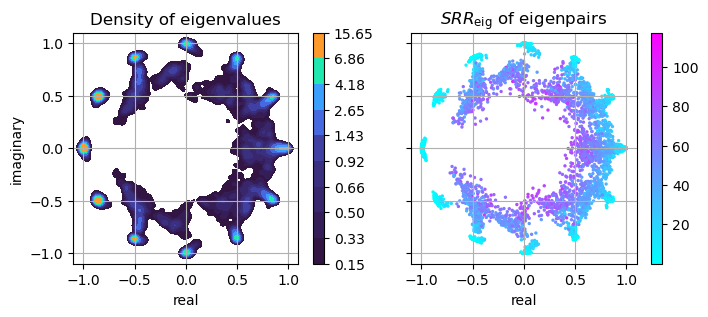

In [25]:
%matplotlib inline
import seaborn as sns
import pandas as pd

eigvals_K, eigvecs_K = K.eigenpairs_left(200)
print(f"plotting {eigvals_K.shape[0]} eigenvalues")

eigfuncs_K = torch.einsum( "nijk,mijk -> nm", obs(C_test).to(torch.complex128), eigvecs_K )
next_eigfuncs_K = eigfuncs_K[1:,:]
prev_eigfuncs_K = eigfuncs_K[:-1,:]
next_eigfuncs_K_pred = prev_eigfuncs_K * eigvals_K.view(1,-1)


residual = 100 * (next_eigfuncs_K - next_eigfuncs_K_pred).abs().pow(2).sum(dim=0)
residual /= eigfuncs_K.abs().pow(2).sum(dim=0)

#region plot eigenvalues
fig, ax = plt.subplots(1,2,figsize=(8,3), sharey=True)
eigvals_df = pd.DataFrame(torch.stack((eigvals_K.real, eigvals_K.imag), dim=1).numpy(), columns=["real", "imaginary"])

sns.kdeplot( eigvals_df, x="real", y="imaginary", fill=True, cmap="turbo", bw_adjust=0.15, ax=ax[0], cbar=True)
ax[0].set_xlim(-1.1, 1.1)
ax[0].set_ylim(-1.1, 1.1)
ax[0].grid()
ax[0].set_title("Density of eigenvalues")

plt.colorbar( plt.scatter( eigvals_K.real, eigvals_K.imag, c=residual, s=2.0, cmap="cool" ) )
ax[1].set_xlim(-1.1, 1.1)
ax[1].set_ylim(-1.1, 1.1)
ax[1].grid()
ax[1].set_title("$SRR_{\\text{eig}}$ of eigenpairs")
ax[1].set_xlabel("real")
plt.show()
#endregion


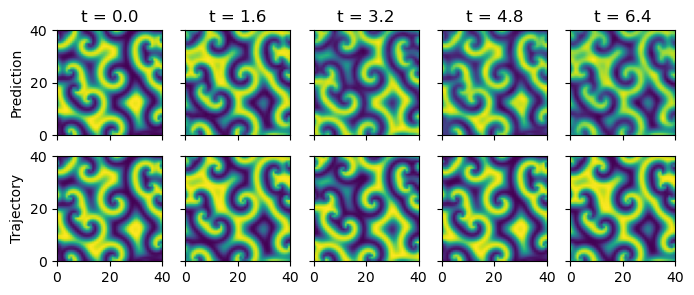

In [31]:
%matplotlib inline

X_test = obs(C_test)

start, n_pred = 0, 40
C_pred = torch.zeros(n_pred, *C.shape[1:])
X_pred = torch.zeros(n_pred, *X.shape[1:])
X_pred[0] = X_test[start]
C_pred[0] = rec(X_pred[0])
for j in range(n_pred-1):
    X_pred[j+1] = K( X_pred[j] )
    C_pred[j+1] = rec( X_pred[j+1] )

# plot_trajectory(C_pred[:,0], spw.L, cmap="viridis")
# plot_trajectory(C_test[start:start+n_pred][:,0], spw.L, cmap="viridis")

fig, ax = plt.subplots(2, n_plots, figsize=(n_plots*1.6, 3), sharey=True, sharex=True)
plot_trajectory(C_pred[:,0], ax[0])
plot_trajectory(C_test[start:start+n_pred,0], ax[1])
for i in range(n_plots): ax[0,i].set_title(f"t = {i/n_plots*dt*len(C_pred):.1f}")
ax[0,0].set_ylabel("Prediction")
ax[1,0].set_ylabel("Trajectory")
plt.show()

In [ ]:
%matplotlib qt

fig, ax = plt.subplots(1,2,figsize=(10,5))

x = X[0]
vmin, vmax = C.min(), C.max()
for j in range(X.shape[0]):
    x = K( x )
    ax[0].clear()
    ax[1].clear()
    ax[0].imshow( rec( x.real )[0].float().numpy(), vmin=vmin, vmax=vmax )
    ax[1].imshow( C[j,0].float().numpy(), vmin=vmin, vmax=vmax )
    plt.pause(0.1)
plt.show()

KeyboardInterrupt: 

QSocketNotifier: Invalid socket 90 and type 'Read', disabling...


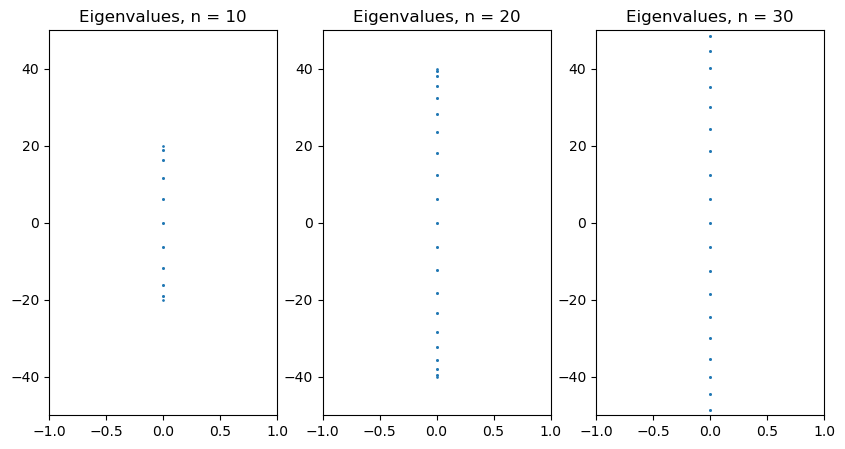

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(1,3,figsize=(10,5))
for i,n in enumerate([10,20,30]):
    L = 1
    dx = L / n
    I = torch.eye(n)
    Lap = (torch.roll(I, -1, 0) - 2*I + torch.roll(I, 1, 0) ) / dx**2


    Lap = torch.cat(( torch.zeros_like(I), Lap), dim=0)
    B = torch.cat(( I, torch.zeros_like(I)), dim=0)
    Lap = torch.cat((Lap,B), dim=1)
    evs, _ = torch.linalg.eig(Lap)
    ax[i].scatter(evs.real, evs.imag, s=0.9)
    ax[i].set_xlim(-1.0, 1.0)
    ax[i].set_ylim(-50.0, 50.0)
    ax[i].set_title(f"Eigenvalues, n = {n}")

plt.show()